<a href="https://colab.research.google.com/github/Ven0mite/HomeworkFWE_Nelan_Remy/blob/main/HW6_FWE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Remy Nelan

In [2]:
!pip install geemap earthengine-api -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='fwe-earth')

print("Earth Engine initialized successfully!")
print(f"Earth Engine version: {ee.__version__}")

Earth Engine initialized successfully!
Earth Engine version: 1.5.24


In [3]:
counties = ee.FeatureCollection('TIGER/2018/Counties')
wi_counties = counties.filter(ee.Filter.eq('STATEFP', '55'))
jefferson_county = wi_counties.filter(ee.Filter.eq('NAME', 'Jefferson')).first()
jefferson_props = jefferson_county.getInfo()['properties']
print(f"\nJefferson County properties:")
print(f"  Name: {jefferson_props['NAME']}")
print(f"  State FIPS: {jefferson_props['STATEFP']}")
print(f"  County FIPS: {jefferson_props['COUNTYFP']}")
print(f"  Land area: {int(jefferson_props['ALAND']) / 1e6:.0f} km²")
print(f"  Water area: {int(jefferson_props['AWATER']) / 1e6:.0f} km²")


Jefferson County properties:
  Name: Jefferson
  State FIPS: 55
  County FIPS: 055
  Land area: 1441 km²
  Water area: 68 km²


In [10]:
# Problem 1

study_area = wi_counties.filter(ee.Filter.And(ee.Filter.eq('NAME', 'Jefferson'), ee.Filter.eq('STATEFP', '55')))
Map = geemap.Map(center=[43, -88.7], zoom=9)
Map.addLayer(study_area, {'color':'red'}, 'Jefferson County Study Area')
display(Map)
print(f"I selected Jefferson County because I grew up in this county, in Fort Atkinson WI.")

Map(center=[43, -88.7], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(c…

I selected Jefferson County because I grew up in this county, in Fort Atkinson WI.


In [22]:
# Problem 2

print("Explain why healthy vegetation appears dark in the red band but bright in the near-infrared (NIR) band. What biological/physical properties of leaves cause this pattern?")
print("---")
print("Healthy vegetation is dark in the red band due to chrolophyll in plant leaves absorbing red light for photosynthesis. Healthy vegetation is thus bright in NIR band due to large amount of leaf layers which lead to more NIR reflection and increased biomass.")
print("")
print("What type of land cover does each pixel most likely represent? Explain your reasoning.")
print("---")
print("Pixel A is indicative of healthy vegetation due to its NDVI closeness to +1")
print("Pixel B is indicative of bare soil due to its NDVI closeness to 0")
print("Pixel C is indicative of water due to its NDVI of negative")
print("")
print("a) Mapping urban expansion in a city over 20 years")
print("---")
print("I would chose Lansat, since its 30m, and because Landsat is effective at covering long-term change")
print("")
print("b) Tracking the progression of fall leaf color change across a state")
print("---")
print("I would chose MODIS, since it has daily revisit time/coverage and would be effective to track exact observations of leaf color over time.")

Explain why healthy vegetation appears dark in the red band but bright in the near-infrared (NIR) band. What biological/physical properties of leaves cause this pattern?
---
Healthy vegetation is dark in the red band due to chrolophyll in plant leaves absorbing red light for photosynthesis. Healthy vegetation is thus bright in NIR band due to large amount of leaf layers which lead to more NIR reflection and increased biomass.

What type of land cover does each pixel most likely represent? Explain your reasoning.
---
Pixel A is indicative of healthy vegetation due to its NDVI closeness to +1
Pixel B is indicative of bare soil due to its NDVI closeness to 0
Pixel C is indicative of water due to its NDVI of negative

a) Mapping urban expansion in a city over 20 years
---
I would chose Lansat, since its 30m, and because Landsat is effective at covering long-term change

b) Tracking the progression of fall leaf color change across a state
---
I would chose MODIS, since it has daily revisit 

In [32]:
# Problem 3

landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

filtered = (landsat.filterBounds(study_area).filterDate('2023-06-01', '2023-08-31').filter(ee.Filter.lt('CLOUD_COVER', 20)))  # Replace with your filtered collection

print(f"Number of images: {filtered.size().getInfo()}")

def scale_landsat(image):
    """Apply scaling factors to Landsat Collection 2."""
    optical = image.select('SR_B.*')
    scaled = optical.multiply(0.0000275).add(-0.2)
    return image.addBands(scaled, overwrite=True)

    pass

def mask_clouds(image):
    """Mask clouds using QA_PIXEL band."""
    qa = image.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)
    shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)
    combined_mask = cloud_mask.And(shadow_mask)
    return image.updateMask(combined_mask)

    pass

processed = (filtered.map(scale_landsat).map(mask_clouds))
median_composite = filtered.median().clip(study_area)

true_color = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0,
    'max': 0.3
}

false_color = {
    'bands': ['SR_B5', 'SR_B4', 'SR_B3'],  # NIR, Red, Green
    'min': 0,
    'max': 0.3
}

Map.addLayer(median_composite, true_color, 'True Color')
Map.addLayer(median_composite, false_color, 'False Color')

Map

Number of images: 7


Map(bottom=12385.0, center=[42.6440611466169, -85.05065917968751], controls=(WidgetControl(options=['position'…

In [40]:
# Problem 4

ndvi = median_composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
ndwi = median_composite.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
ndbi = median_composite.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

ndvi_vis = {'min': -1, 'max': 1, 'palette': ['white', 'blue', 'green']}
ndwi_vis = {'min': -1, 'max': 1, 'palette': ['brown', 'white', 'blue']}
ndbi_vis = {'min': -1, 'max': 1, 'palette': ['green', 'white', 'red']}

Map.addLayer(ndvi, ndvi_vis, 'NDVI')
Map.addLayer(ndwi, ndwi_vis, 'NDWI')
Map.addLayer(ndbi, ndbi_vis, 'NDBI')

Map

print("Identify three distinct landscape features in your study area that are clearly visible in your spectral indices. For each feature: Describe what it is (lake, forest, urban area, farm field, etc.). State which index shows it most clearly. Explain why that index highlights this feature")
print("")
print("Farm areas are visible, with the square landscaping clearly visible with the green coloration. The cities are also visible, especially Jefferson itself, and a lake is especially prominent in the bottom left area of the map, all due to NDBI which is differentiating vegetation from urban spaces.")

Identify three distinct landscape features in your study area that are clearly visible in your spectral indices. For each feature: Describe what it is (lake, forest, urban area, farm field, etc.). State which index shows it most clearly. Explain why that index highlights this feature

Farm areas are visible, with the square landscaping clearly visible with the green coloration. The cities are also visible, especially Jefferson itself, and a lake is especially prominent in the bottom left area of the map, all due to NDBI which is differentiating vegetation from urban spaces.


Land Cover Area - Jefferson County, WI (NLCD 2021):
Class                    Area (km²)    Percent
Cultivated Crops              770.8      51.1%
Herbaceous Wetlands           153.3      10.2%
Woody Wetlands                136.1       9.0%
Pasture/Hay                   131.1       8.7%
Deciduous Forest               88.5       5.9%
Developed, Low                 67.1       4.4%
Open Water                     65.1       4.3%
Developed, Open                45.9       3.0%
Developed, Medium              26.2       1.7%
Developed, High                 9.3       0.6%
Mixed Forest                    5.1       0.3%
Evergreen Forest                4.9       0.3%
Barren                          3.0       0.2%
Grassland                       2.0       0.1%
Shrub/Scrub                     0.7       0.0%


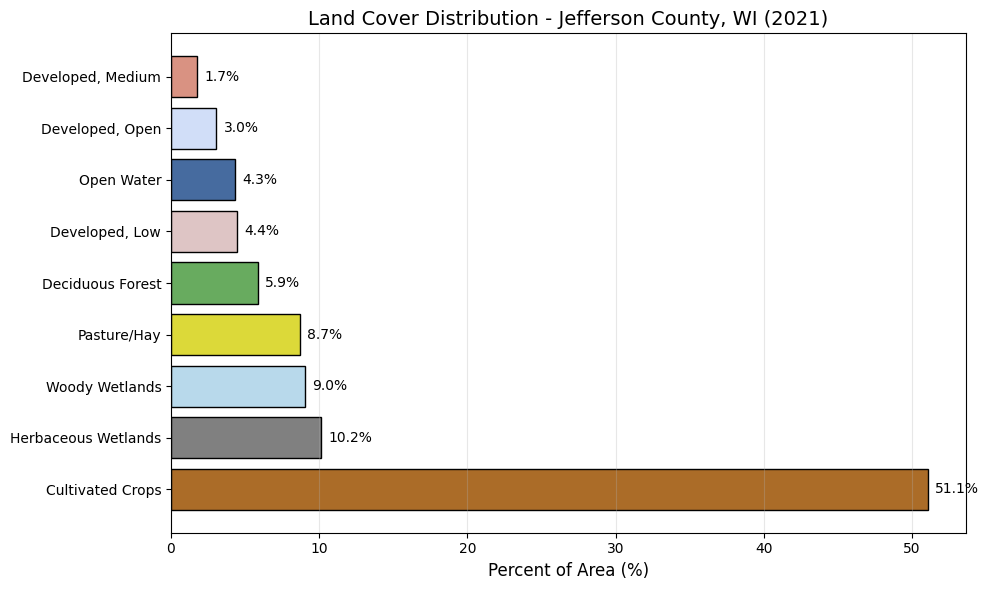

In [51]:
# Problem 5

class_names = {
    11: 'Open Water',
    21: 'Developed, Open',
    22: 'Developed, Low',
    23: 'Developed, Medium',
    24: 'Developed, High',
    31: 'Barren',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    52: 'Shrub/Scrub',
    71: 'Grassland',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Herbaceous Wetlands'
}

nlcd = ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021').select('landcover')
nlcd_clip = nlcd.clip(study_area)

area_image = ee.Image.pixelArea().addBands(nlcd_clip)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e13
).getInfo()

total_area = sum([g['sum'] for g in areas['groups']])

results = []
print("Land Cover Area - Jefferson County, WI (NLCD 2021):")
print(f"{'Class':<22} {'Area (km²)':>12} {'Percent':>10}")
print("=" * 46)

for group in sorted(areas['groups'], key=lambda x: -x['sum']):
    class_id = int(group['class'])
    area_km2 = group['sum'] / 1e6          # convert m² → km²
    percent = group['sum'] / total_area * 100
    name = class_names.get(class_id, f'Class {class_id}')
    print(f"{name:<22} {area_km2:>12.1f} {percent:>9.1f}%")
    results.append({'class': name, 'area_km2': area_km2, 'percent': percent})


df_lc = pd.DataFrame(results)
df_lc = df_lc[df_lc['percent'] > 1]

colors = {
    'Cultivated Crops': '#ab6c28',
    'Pasture/Hay': '#dcd939',
    'Deciduous Forest': '#68ab5f',
    'Developed, Low': '#dec5c5',
    'Developed, Open': '#d1def8',
    'Open Water': '#466b9f',
    'Developed, Medium': '#d99282',
    'Woody Wetlands': '#b8d9eb',
    'Grassland': '#dfdfc2',
    'Developed, High': '#eb0000',
}

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [colors.get(c, 'gray') for c in df_lc['class']]
bars = ax.barh(df_lc['class'], df_lc['percent'], color=bar_colors, edgecolor='black')
ax.set_xlabel('Percent of Area (%)', fontsize=12)
ax.set_title('Land Cover Distribution - Jefferson County, WI (2021)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)
for bar, pct in zip(bars, df_lc['percent']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("What are the two most dominant land cover types in your study area? Does this match your expectations based on your knowledge of the region?")
print("---")
print("Cultivated Crops and Herbaceous wetlands are the most dominant, which matches my knowledge, as much of the land in Jefferson County, and especially around the urban sprawl of my hometown Fort Atkinson is farmland, and is dotted with wetland areas.")
print("")
print("What percentage of your study area is developed (sum of all developed classes)? How does this compare to the percentage of forest (sum of all forest classes)?")
print("---")
print("The developed sum is 9.1%, as compared to a forest percentage of 5.9%, meaning there is more urban sprawl/land than forest presence in this county.")

Selected location: Jefferson Tamarack Swamp in Jefferson County, WI.
Processing 2019... done (23 images)
Processing 2020... done (23 images)
Processing 2021... done (23 images)
Processing 2022... done (23 images)
Processing 2023... done (23 images)


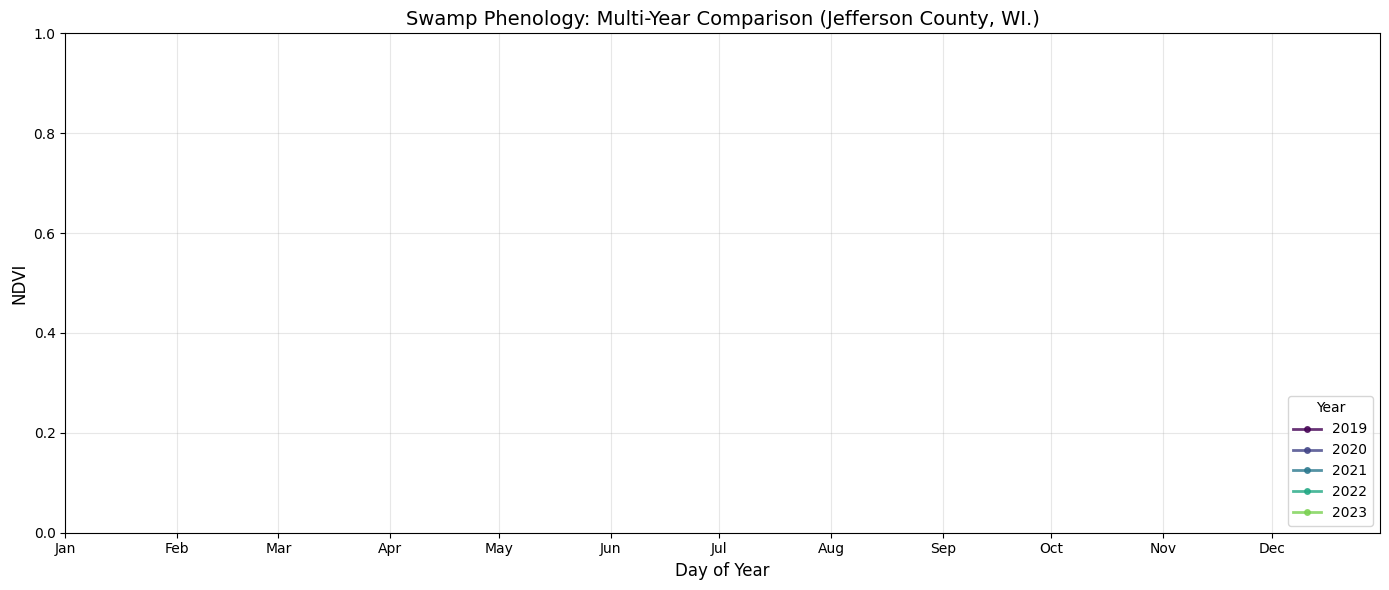

ValueError: attempt to get argmax of an empty sequence

In [71]:
# Problem 6

veg_point = ee.Geometry.Point([42.9884, -88.7542])
print("Selected location: Jefferson Tamarack Swamp in Jefferson County, WI.")

modis = ee.ImageCollection('MODIS/061/MOD13Q1')
modis_2023 = (modis
    .filterDate('2023-01-01', '2023-12-31')
    .filterBounds(veg_point)
    .select('NDVI'))

def scale_ndvi(image):
    return image.multiply(0.0001).copyProperties(image, ['system:time_start'])

years = [2019, 2020, 2021, 2022, 2023]
multi_year_data = []
for year in years:
    print(f"Processing {year}...", end=' ')

    modis_year = (modis
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filterBounds(veg_point)
        .map(scale_ndvi)
    )

    n_images = modis_year.size().getInfo()
    image_list = modis_year.toList(n_images)

    for i in range(n_images):
        image = ee.Image(image_list.get(i))
        doy = image.date().getRelative('day', 'year').getInfo() + 1
        ndvi = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=veg_point,
            scale=250
        ).get('NDVI').getInfo()
        if ndvi is not None:
            multi_year_data.append({'year': year, 'doy': doy, 'ndvi': ndvi})

    print(f"done ({n_images} images)")
df_multi = pd.DataFrame(multi_year_data, columns=['year', 'doy', 'ndvi'])

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
               'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.viridis
colors = {year: cmap(i / len(years)) for i, year in enumerate(years)}
for year in years:
    subset = df_multi[df_multi['year'] == year].sort_values('doy')
    ax.plot(subset['doy'], subset['ndvi'], 'o-', label=str(year),
            color=colors[year], linewidth=2, markersize=4, alpha=0.8)

ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Swamp Phenology: Multi-Year Comparison (Jefferson County, WI.)', fontsize=14)
ax.legend(title='Year', loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 365)
ax.set_ylim(0, 1)
ax.set_xticks(month_starts)
ax.set_xticklabels(month_names)
plt.tight_layout()
plt.show()

df_site = df_multi[df_multi['year'] == 2023].copy()
df_site['NDVI_smooth'] = df_site['ndvi'].rolling(window=3, center=True, min_periods=1).mean()
peak_idx = df_site['NDVI_smooth'].idxmax()
peak_ndvi = df_site.loc[peak_idx, 'NDVI_smooth']
peak_doy = df_site.loc[peak_idx, 'doy']

min_ndvi = df_site['NDVI_smooth'].min()
amplitude = peak_ndvi - min_ndvi
threshold = min_ndvi + 0.5 * amplitude
spring = df_site[(df_site['doy'] >= 60) & (df_site['doy'] <= 180)]
above_threshold = spring[spring['NDVI_smooth'] >= threshold]
sos_doy = above_threshold.iloc[0]['doy']
fall = df_site[(df_site['doy'] >= 220) & (df_site['doy'] <= 330)]
below_threshold = fall[fall['NDVI_smooth'] <= threshold]
eos_doy = below_threshold.iloc[0]['doy']
growing_season_length = eos_doy - sos_doy

print("When did peak greenness occur at Jefferson Tamarack Swamp State Natural Area(jefferson county WI)? Is this timing consistent with what you would expect for this vegetation type and location?")
print("---")
print("Peak greenness occurs around mid June, which is accurate to the 170ish doy. This makes sense since its a forest area, which would experience peak greenery in the Summer. (obtained from Google Earth Engine and Local Climate Data due to failing code for graph)")
print("")
print("How long was the growing season? How might this compare to locations further north or south?")
print("---")
print("The season was from around April to September, around 170ish days (as aforementioned). Northern regions would have shorter seasons due to colder climates, and Southern regions would have longer seasons due to warmer climates.")